<a href="https://colab.research.google.com/github/Eikthyrnir/uam-cv-sim-to-real-interpretability/blob/main/DIMO_detection_sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wizja komputerowa, dane syntetyczne i testowanie architektur

**Projekty dla studentów V roku / ostatniego semestru. Realizacja w parach dwuosobowych.**

# **Zasady ogólne**

**Każdy projekt jest realizowany przez dokładnie dwie osoby.** Temat ma prowadzić do kompletnego, mierzalnego eksperymentu z użyciem modeli wizyjnych: klasyfikacji, detekcji, segmentacji, pseudoetykietowania, samonadzorowanego uczenia reprezentacji albo analizy luki domenowej. Projekty mogą mocniej akcentować generowanie danych syntetycznych albo testowanie architektur, ale każdy projekt musi kończyć się wynikami ilościowymi i jakościowymi.

· Każda para musi udostępnić publiczne lub dostępne dla prowadzącego repozytorium GitHub z kodem, konfiguracjami, instrukcją uruchomienia, skryptami przygotowania danych i wynikami eksperymentów.

· Każda para musi przygotować dokument wynikowy, najlepiej w formacie PDF lub Google Docs, opisujący cel, dane, metody, architektury, eksperymenty, wyniki, wizualizacje, błędy i ograniczenia.

· Link do repozytorium oraz link do dokumentu wynikowego muszą zostać wpisane do arkusza Google Sheets: [arkusz projektów](https://docs.google.com/spreadsheets/d/1HeEo42lNxoAGrou7ehcJk4KBIXR4Gv7RgMd3FmzLE0I/edit?usp=sharing).

· W arkuszu powinny znaleźć się co najmniej: numer projektu, imiona i nazwiska studentów, link do repozytorium, link do raportu, link do danych/artefaktów/modeli, krótki opis finalnego wariantu eksperymentu oraz status projektu.

· Zbiory danych wskazane poniżej są publicznie dostępne lub powszechnie używane w badaniach. Przed użyciem należy sprawdzić i respektować licencję konkretnego zbioru, obrazu i adnotacji; nie wszystkie zbiory są stricte CC0/public domain.

# **Minimalny zakres wyników**

· Dla lżejszych projektów klasyfikacyjnych lub segmentacyjnych oczekiwane jest około 15-30 sensownych konfiguracji lub wariantów eksperymentalnych.

· Dla cięższych projektów detekcyjnych oczekiwane jest około 8-15 konfiguracji, ale z pełniejszą analizą kosztu obliczeniowego, błędów i transferu domenowego.

· Każdy projekt musi zawierać punkt odniesienia, warianty porównawcze, tabele metryk, wykresy, wizualizacje wyników, przykłady błędów oraz interpretowalność: Grad-CAM, mapy uwagi, aktywacje, filtry lub osadzenia.

· Raport powinien mieć strukturę krótkiego artykułu: wstęp i pytanie badawcze, przegląd literatury, opis danych, metoda, protokół eksperymentów, wyniki, analiza jakościowa, ograniczenia, wnioski i instrukcja reprodukcji.


## **7\. Co sieci naprawdę uczą się z danych syntetycznych? Aktywacje, filtry i skróty decyzyjne**

**Kierunek:** interpretowalność / testowanie architektur

**Zadanie wizyjne:** klasyfikacja lub detekcja

**Publicznie dostępne zbiory danych:** COCO, Open Images, własny zbiór Blender, RarePlanes

**Pytanie badawcze:** Czy model trenowany na syntetykach uczy się obiektu, czy raczej artefaktów renderingu, tła, tekstur i innych skrótów decyzyjnych?

**Opis projektu:** To projekt diagnostyczny. Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych. Następnie analizuje aktywacje warstw, mapy uwagi, Grad-CAM oraz przypadki błędów. Celem jest wykrycie, kiedy syntetyki tworzą bias tła, bias tekstury lub bias kształtu.

**Modele i metody do przetestowania:**

· ResNet/ConvNeXt dla klasyfikacji

· YOLOv10 lub Faster R-CNN dla detekcji

· ViT/DINOv2 dla analizy uwagi

**Wymagane eksperymenty:**

· porównanie 4-5 reżimów danych

· analiza wrażliwości na zasłanianie fragmentów obrazu: usuwanie tła, tekstury, części obiektu

· UMAP/t-SNE osadzeń cech dla danych rzeczywistych i syntetycznych

· analiza 50 poprawnych i 50 błędnych predykcji

**Wymagane wyniki i analiza:**

· dokładność lub mAP

· co najmniej 50 wizualizacji Grad-CAM / mapy uwagi

· mapy filtrów lub aktywacji wybranych warstw

· ranking najczęstszych skrótów decyzyjnych

· sekcja w raporcie: kiedy syntetyki pomagają, a kiedy szkodzą

**Linki:** [pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam); [DINOv2](https://github.com/facebookresearch/dinov2); [COCO](https://cocodataset.org/); [Open Images](https://storage.googleapis.com/openimages/web/index.html); [RarePlanes](https://www.iqt.org/library/the-rareplanes-dataset); [ConvNeXt V2](https://github.com/facebookresearch/ConvNeXt-V2)


In [1]:
# Set seed for reproducibility
import torch

RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)

## Step 1: Mount Google Drive
To avoid downloading massive files every time your session disconnects, we can save the dataset to Google Drive (if you have enough space). Otherwise, you can use the local `/content/` storage, but remember it will be cleared after the session ends.

In [2]:
from google.colab import drive
import os

# Mount Google Drive (Optional but recommended if you have space)
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Download the Dataset

### Download from official DIMO links to Google Drive (Slow)

In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO'

os.makedirs(PROJECT_DIR, exist_ok=True)

In [ ]:
TAR_PATH = os.path.join(PROJECT_DIR, "dimo.tar")

In [ ]:
DATASET_URL = "https://datasets.ilabt.imec.be/dimo/tar/dimo.tar"


# Download only if it doesn't exist yet
if not os.path.exists(TAR_PATH):
    !wget -O "{TAR_PATH}" "{DATASET_URL}"

--2026-05-27 19:20:14--  https://datasets.ilabt.imec.be/dimo/tar/dimo.tar
Resolving datasets.ilabt.imec.be (datasets.ilabt.imec.be)... 193.191.148.201, 2001:6a8:1d80:26::201
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14153728 (13M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo.tar’

/content/drive/MyDr 100%[===================>]  13.50M  5.44MB/s    in 2.5s    

2026-05-27 19:20:18 (5.44 MB/s) - ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo.tar’ saved [14153728/14153728]



#### Download Real-World Data (RealSense D415)
Since the project involves comparing real and synthetic data, let's start with the smallest real-world image archive (RealSense D415, 12.7 GB). Replace the URL below with the actual link to this archive.

In [ ]:
REAL_DATA_URL = "https://datasets.ilabt.imec.be/dimo/tar/real_d415.tar"
REAL_TAR_PATH = os.path.join(PROJECT_DIR, "real_d415.tar")

if not os.path.exists(REAL_TAR_PATH):
    !wget -O "{REAL_TAR_PATH}" "{REAL_DATA_URL}"

#### Download dimo small

In [ ]:
REAL_DATA_URL = "https://datasets.ilabt.imec.be/dimo/tar/dimo_small.tar"
REAL_TAR_PATH = os.path.join(PROJECT_DIR, "dimo_small.tar")

if not os.path.exists(REAL_TAR_PATH):
    !wget -O "{REAL_TAR_PATH}" "{REAL_DATA_URL}"

--2026-05-28 13:15:38--  https://datasets.ilabt.imec.be/dimo/tar/dimo_small.tar
Resolving datasets.ilabt.imec.be (datasets.ilabt.imec.be)... 193.191.148.201, 2001:6a8:1d80:26::201
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 65892688896 (61G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo_small.tar’

/content/drive/MyDr   1%[                    ]   1.01G  9.15MB/s    in 97s     

2026-05-28 13:17:16 (10.6 MB/s) - Connection closed at byte 1080401777. Retrying.

--2026-05-28 13:17:17--  (try: 2)  https://datasets.ilabt.imec.be/dimo/tar/dimo_small.tar
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 65892688896 (61G), 64812287119 (60G) remaining [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magister

### Download from Tim's Google Drive (much faster)

In [4]:
!mkdir /content/DIMO_archives

In [ ]:
# !gdown --id 1py7xaJpql7a6SrS9N5JF0xANLpbYZ4yM -O /content/DIMO_archives/dimo.tar

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1py7xaJpql7a6SrS9N5JF0xANLpbYZ4yM
To: /content/DIMO_archives/dimo.tar
100% 14.2M/14.2M [00:00<00:00, 81.7MB/s]


In [ ]:
# !gdown --id 1TyINalV-nfdbbalOzcebp4tH9_K-ibI5 -O /content/DIMO_archives/real_d415.tar

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1TyINalV-nfdbbalOzcebp4tH9_K-ibI5
From (redirected): https://drive.google.com/uc?id=1TyINalV-nfdbbalOzcebp4tH9_K-ibI5&confirm=t&uuid=d9e7b407-441f-4897-8452-d57a85995fc6
To: /content/DIMO_archives/real_d415.tar
100% 12.7G/12.7G [02:55<00:00, 72.6MB/s]


In [2]:
# !gdown 1xCHhENLfAZDgOErz4TWL-FhMBnJ8uhVO -O /content/DIMO_archives/dimo_small.tar

Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1xCHhENLfAZDgOErz4TWL-FhMBnJ8uhVO

but Gdown can't. Please check connections and permissions.


In [3]:
# alternative
!cp /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo_small.tar /content/DIMO_archives/dimo_small.tar

cp: cannot create regular file '/content/DIMO_archives/dimo_small.tar': No such file or directory


In [63]:
!gdown 1UZghk46xe_9E0ylHc5ONcBYWHsX3Qs6U -O /content/DIMO_archives/DIMO_experiment_subsets.tar

Downloading...
From (original): https://drive.google.com/uc?id=1LPzX86HdSOyGCpd-lvzappiN_AW81m74
From (redirected): https://drive.google.com/uc?id=1LPzX86HdSOyGCpd-lvzappiN_AW81m74&confirm=t&uuid=c633b36c-e0af-4091-8bc3-e5cfbfaa9c7b
To: /content/DIMO_archives/DIMO_experiment_subsets.tar
100% 6.14G/6.14G [00:30<00:00, 202MB/s]


In [ ]:
!cd /content/DIMO_archives && ls -la

total 64348384
drwxr-xr-x 2 root root        4096 May 29 07:41 .
drwxr-xr-x 1 root root        4096 May 29 07:41 ..
-rw------- 1 root root 65892688896 May 29 08:10 dimo_small.tar


## Upzip

### 10k Subset of dimo-small

In [66]:
!tar -xf /content/DIMO_archives/DIMO_experiment_subsets.tar -C /content

### dimo-small

In [5]:
!tar -xf /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo_small.tar -C /content

Streaming output truncated to the last 5000 lines.
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar

In [ ]:
!tar -xf /content/DIMO_archives/dimo_small.tar -C /content

Streaming output truncated to the last 5000 lines.
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar

### Full-size (HD) real data

In [ ]:
!tar -xf /content/DIMO_archives/dimo.tar -C /content

tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.metadata:_kMDItemUserTags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.mac

In [ ]:
!tar -xf /content/DIMO_archives/real_d415.tar -C /content/dimo

## Step 6: Parse Annotations and Visualize Ground Truth


In [6]:
# We will use trimesh to easily load the 3D .ply models
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 10.8 MB/s eta 0:00:00


### Load Dataset using Official DIMO Loader
Instead of parsing JSONs manually, let's use the provided `dimo_loader.py` to structure the dataset.

In [7]:
!git clone https://github.com/pderoovere/dimo.git /content/dimo_repo

Cloning into '/content/dimo_repo'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 221 (delta 88), reused 185 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (221/221), 6.44 MiB | 43.98 MiB/s, done.
Resolving deltas: 100% (88/88), done.


In [8]:
import sys
import os
# Ensure the current directory is in the path to import dimo_loader
if '/content' not in sys.path:
    sys.path.append('/content')

from dimo_repo.scripts.dimo_loader import DimoLoader
from pathlib import Path

In [11]:
# Set path to the extracted dimo dataset folder
dimo_ds_path = Path('/content/dimo_small')
# dimo_ds_path = Path('/content/DIMO_experiment_subsets')

In [12]:
dimo_loader = DimoLoader()

dimo_ds = dimo_loader.load(
    dimo_ds_path,
    cameras=[
        "real_d415",
        "real_jaigo",
        "real_l515",
      # exclude real_mvbluefox since this folder contains gray folder for gray images instead of rgb.
      # DimoLoader can't handle this and it's also easier to only train on rgb images
      #  "real_mvbluefox",
        "sim_jaigo"
    ])

# dimo_ds = dimo_loader.load(
#     dimo_ds_path,
#     cameras=[
#         "real_only",
#         "sim_all",
#       # exclude real_mvbluefox since this folder contains gray folder for gray images instead of rgb.
#       # DimoLoader can't handle this and it's also easier to only train on rgb images
#       #  "real_mvbluefox",
#         "sim_weak_dr",
#         "sim_strong_dr",
#         "mixed",
#     ])

Loading real_d415
Loading real_jaigo
Loading real_l515
Loading sim_jaigo


In [13]:
import numpy as np
import trimesh
import os
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

# Cache for 3D models to speed up projection across multiple images
models_dir = dimo_ds_path / "models"
models_cache = {}

def get_model_vertices(obj_id):
    if obj_id not in models_cache:
        model_path = os.path.join(models_dir, f"obj_{int(obj_id):06d}.ply")
        mesh = trimesh.load(model_path)
        models_cache[obj_id] = mesh.vertices
    return models_cache[obj_id]

## Dataset insights

In [14]:
import pandas as pd

# Prepare a list to hold all the flattened records
records = []

# Iterate through the top-level keys (cameras and 'models')
for cam_name, scenes in dimo_ds.items():
    if cam_name == 'models':
        continue # Skip the 3D models metadata for the main dataframe

    for scene_list_idx, scene in enumerate(scenes):

        scene_id = scene['id']
        for image_list_idx, img in enumerate(scene['images']):
            img_id = img['id']
            img_path = str(img['path'])
            num_objects = len(img['objects'])

            if not os.path.exists(img['path']):
                print(f"ERROR: file not exists: {img['path']}")
                continue

            image_data = {
                    'camera': cam_name,
                    'scene_id': scene_id,
                    'scene_list_idx': scene_list_idx,
                    'image_id': img_id,
                    'image_list_idx': image_list_idx,
                    'image_path': img_path,
                    'total_objects_in_image': num_objects
                }
            # Use .get() to safely handle cases where scene_info might be missing
            image_data.update(img.get('scene_info', {}))

            # --------- We probably don't need row per obj, row per img is enough --------
            # for obj in img['objects']:
            #     # Crucial: make a copy so we don't overwrite previous objects from the same image
            #     obj_record = image_data.copy()
            #     obj_record['object_id'] = obj['id']

            #     records.append(obj_record)

            records.append(image_data)

# Create the DataFrame
df_dimo = pd.DataFrame(records)

In [15]:
import pandas as pd

# Group by the specified columns and count occurrences
# dropna=False ensures we don't drop rows where fields like 'exposure' are NaN (e.g., real images)
grouped_counts = df_dimo.groupby(
    ['light', 'exposure', 'environment_rotation', 'carrier'],
    dropna=False
).size().reset_index(name='count')

# Sort by count descending to see the most common configurations
grouped_counts = grouped_counts.sort_values(by='count', ascending=False)

print(f"Total images: {len(df_dimo)}")
print(f"Total unique combinations: {len(grouped_counts)}")
display(grouped_counts.head(20))

Total images: 550992
Total unique combinations: 30239


,light,exposure,environment_rotation,carrier,count
16209,lightRoomImage_hdr,11.000000,0.000000,2,30355
10526,darkRoomImage_hdr,7.000000,180.000000,1,21008
10525,darkRoomImage_hdr,7.000000,180.000000,0,20800
16207,lightRoomImage_hdr,11.000000,0.000000,0,20800
16208,lightRoomImage_hdr,11.000000,0.000000,1,20592
10528,darkRoomImage_hdr,9.500000,180.000000,2,11505
10527,darkRoomImage_hdr,7.000000,180.000000,2,9087
4,1,NaN,NaN,1,3939
0,0,NaN,NaN,0,3900
1,0,NaN,NaN,1,3900


In [16]:
df_dimo.groupby(
    ['light'],
    dropna=False
).size().reset_index(name='count').sort_values(by='count', ascending=False)

,light,count
20,lightRoomImage_hdr,71747
13,darkRoomImage_hdr,62400
9,blinds_4k,12597
3,abandoned_games_room_01_4k,12545
6,artist_workshop_4k,12519
7,auto_service_4k,12506
4,abandoned_workshop_4k,12454
10,boiler_room_4k,12454
2,abandoned_factory_canteen_02_4k,12428
8,autoshop_01_4k,12428


In [17]:
df_dimo.groupby(
    ['camera', 'total_objects_in_image'],
    dropna=False
).size().reset_index(name='count').sort_values(by='total_objects_in_image', ascending=True)

,camera,total_objects_in_image,count
0,real_d415,1,936
6,real_jaigo,1,936
12,real_l515,1,936
18,sim_jaigo,1,66443
13,real_l515,4,26
1,real_d415,4,26
19,sim_jaigo,4,1326
7,real_jaigo,4,26
14,real_l515,5,5915
20,sim_jaigo,5,399490


In [18]:
df_dimo

,camera,scene_id,scene_list_idx,image_id,image_list_idx,image_path,total_objects_in_image,light,carrier,parts,viewpoint,exposure,environment_rotation
0,real_d415,000000,0,1,0,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,0,NaN,NaN
1,real_d415,000000,0,2,1,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,1,NaN,NaN
2,real_d415,000000,0,3,2,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,2,NaN,NaN
3,real_d415,000000,0,4,3,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,3,NaN,NaN
4,real_d415,000000,0,5,4,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
550987,sim_jaigo,000599_70,40583,8,8,/content/dimo_small/sim_jaigo/000599_70/rgb/00...,6,peppermint_powerplant_4k,1,0,8,11.20313,297.206116
550988,sim_jaigo,000599_70,40583,9,9,/content/dimo_small/sim_jaigo/000599_70/rgb/00...,6,peppermint_powerplant_4k,1,0,9,11.20313,297.206116
550989,sim_jaigo,000599_70,40583,10,10,/content/dimo_small/sim_jaigo/000599_70/rgb/00...,6,peppermint_powerplant_4k,1,0,10,11.20313,297.206116
550990,sim_jaigo,000599_70,40583,11,11,/content/dimo_small/sim_jaigo/000599_70/rgb/00...,6,peppermint_powerplant_4k,1,0,11,11.20313,297.206116


## Split dataset into subsets

> Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych



In [36]:
import pandas as pd

# 1. Tylko dane rzeczywiste (Only real data)
df_real_only = df_dimo[df_dimo['camera'].str.startswith('real')].copy()

# 2. Tylko dane syntetyczne (All synthetic data)
df_sim_all = df_dimo[df_dimo['camera'] == 'sim_jaigo'].copy()

# Helper to identify 'Real-world lighting' in simulation
real_world_lights = ['lightRoomImage_hdr', 'darkRoomImage_hdr']

# 3. Słaba randomizacja syntetyczna (Weak randomization)
# We'll use simulation data with real-world lighting environments (allowing default rotations)
df_sim_weak_dr = df_sim_all[
    df_sim_all['light'].isin(real_world_lights)
].copy()

# 4. Silna randomizacja syntetyczna (Strong randomization)
# Simulation data with random HDRI lighting and random rotations
df_sim_strong_dr = df_sim_all[
    ~df_sim_all['light'].isin(real_world_lights)
].copy()

print("--- Dataset Splits for the Project ---")
print(f"1. Tylko dane rzeczywiste:       {len(df_real_only)} observations")
print(f"2. Tylko dane syntetyczne (all): {len(df_sim_all)} observations")
print(f"3. Słaba randomizacja:           {len(df_sim_weak_dr)} observations")
print(f"4. Silna randomizacja:           {len(df_sim_strong_dr)} observations")
print(f"5. Mieszanka danych (Real+Strong): would be calculated later to ensure 50/50 real/sim data split")


--- Dataset Splits for the Project ---
1. Tylko dane rzeczywiste:       23400 observations
2. Tylko dane syntetyczne (all): 527592 observations
3. Słaba randomizacja:           134147 observations
4. Silna randomizacja:           393445 observations
5. Mieszanka danych (Real+Strong): would be calculated later to ensure 50/50 real/sim data split


In [37]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

N_IMAGES_TO_KEEP = 10_000

export_dir = '/content/DIMO_experiment_subsets'
os.makedirs(export_dir, exist_ok=True)

regimes = {
    'real_only': df_real_only.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_all': df_sim_all.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_weak_dr': df_sim_weak_dr.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_strong_dr': df_sim_strong_dr.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
}

df_mixed = pd.concat([
                regimes['real_only'],
                regimes['sim_all']
            ], ignore_index=True)

for name, df in regimes.items():
    print(f"\nProcessing {name}...")

    # Copy images and entire scene metadata to the new folders
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Copying Train Images"):
        orig_img_path = row['image_path']
        if os.path.exists(orig_img_path):
            # Keep the camera directory in the path to avoid overwriting scenes with the same ID from different cameras
            new_img_path = str(orig_img_path).replace(str(dimo_ds_path), str(export_dir))
            os.makedirs(os.path.dirname(new_img_path), exist_ok=True)
            shutil.copy(orig_img_path, new_img_path)

            # Copy metadata: all json files from the scene folder
            orig_scene_dir = os.path.dirname(os.path.dirname(orig_img_path))
            new_scene_dir = os.path.dirname(os.path.dirname(new_img_path))

            for file_name in os.listdir(orig_scene_dir):
                if file_name.endswith('.json'):
                    orig_file = os.path.join(orig_scene_dir, file_name)
                    new_file = os.path.join(new_scene_dir, file_name)
                    if not os.path.exists(new_file):
                        shutil.copy(orig_file, new_file)
        else:
            print(f"ERROR: no such file {orig_img_path}")

# Copy the models directory
models_src = os.path.join(dimo_ds_path, 'models')
models_dst = os.path.join(export_dir, 'models')
if os.path.exists(models_src) and not os.path.exists(models_dst):
    print("Copying models directory...")
    shutil.copytree(models_src, models_dst)



Processing real_only...


Copying Train Images: 100%|██████████| 10000/10000 [00:08<00:00, 1151.07it/s]



Processing sim_all...


Copying Train Images: 100%|██████████| 10000/10000 [00:16<00:00, 613.45it/s]



Processing sim_weak_dr...


Copying Train Images: 100%|██████████| 10000/10000 [00:13<00:00, 762.38it/s]



Processing sim_strong_dr...


Copying Train Images: 100%|██████████| 10000/10000 [00:12<00:00, 830.27it/s]

Copying models directory...


In [43]:
# Change '/content' to your specific folder path if needed.
# To count .png files instead, change "*.jpg" to "*.png"
!find /content/DIMO_experiment_subsets/sim_jaigo/ -type f -name "*.png" | wc -l

29618


In [44]:
!du -sh /content/DIMO_experiment_subsets

5.6G	/content/DIMO_experiment_subsets


In [47]:
!tar -cf "/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/DIMO_experiment_subsets.tar" \
     -C /content DIMO_experiment_subsets

## Create PyTorch Dataset

Implement a PyTorch Dataset class to load a subset of the DIMO data, returning images, labels and bounding boxes

In [41]:
import torch
import os
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

class DimoDetectionDataset(Dataset):
    def __init__(self, native_dimo_ds, image_set):
        self.samples = []
        self.target_size = (224, 224)
        # For torchvision detectors, we usually just convert to tensor (values 0-1)
        # Normalization is often handled inside the model (e.g., Faster R-CNN)
        self.transform = transforms.Compose([
            transforms.Resize(self.target_size),
            transforms.ToTensor(),
        ])

        # Iterate over the dataframe rows
        for idx, row in image_set.iterrows():
            cam = row['camera']
            # Use the new explicit list indices to fetch directly
            scene_idx = int(row['scene_list_idx'])
            img_idx = int(row['image_list_idx'])

            # Direct list indexing! Extremely fast O(1) lookup.
            try:
                img_data = native_dimo_ds[cam][scene_idx]['images'][img_idx]
            except (KeyError, IndexError):
                continue

            img_path = img_data['path']

            # Skip if the file is missing from the disk
            if not os.path.exists(img_path):
                continue

            K = np.array(img_data['camera']['K']).reshape(3, 3)

            bboxes = []
            labels = []

            for obj in img_data['objects']:
                if 'model_2cam' in obj:
                    obj_id = obj['id']
                    pose = np.array(obj['model_2cam'])
                    R = pose[:3, :3]
                    t = pose[:3, 3].reshape(3, 1)

                    # Project 3D to 2D to get the bounding box
                    vertices = get_model_vertices(obj_id)
                    pts_cam = (R @ vertices.T) + t
                    pts_2d = K @ pts_cam

                    u = pts_2d[0, :] / pts_2d[2, :]
                    v = pts_2d[1, :] / pts_2d[2, :]

                    xmin, xmax = np.min(u), np.max(u)
                    ymin, ymax = np.min(v), np.max(v)

                    # Add box and label (assume all objects are class 1 for now, 0 is background)
                    bboxes.append([xmin, ymin, xmax, ymax])
                    labels.append(1)

            if bboxes:
                self.samples.append({
                    'img_path': img_path,
                    'bboxes': torch.tensor(bboxes, dtype=torch.float32),
                    'labels': torch.tensor(labels, dtype=torch.int64)
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['img_path']).convert('RGB')
        orig_w, orig_h = img.size

        # Resize bounding boxes
        target_w, target_h = self.target_size
        scale_x = target_w / orig_w
        scale_y = target_h / orig_h

        boxes = sample['bboxes'].clone()
        boxes[:, 0] *= scale_x # xmin
        boxes[:, 2] *= scale_x # xmax
        boxes[:, 1] *= scale_y # ymin
        boxes[:, 3] *= scale_y # ymax

        # Transform image
        img_tensor = self.transform(img)

        target = {}
        target['boxes'] = boxes
        target['labels'] = sample['labels']

        return img_tensor, target


def collate_fn(batch):
    # Faster R-CNN expects a tuple of (images, targets) rather than stacked tensors
    # because the number of bounding boxes varies per image.
    return tuple(zip(*batch))

In [42]:
# Test with a slice of your df_mixed dataframe to simulate controlling the size externally
detection_train_dataset = DimoDetectionDataset(dimo_ds, df_real_only.head(1_000))
print(f"Created detection dataset with {len(detection_train_dataset)} samples.")

# fetching a test sample
img_t, target = detection_train_dataset[0]
print("Image tensor shape:", img_t.shape)
print("Bounding Boxes:\n", target['boxes'])
print("Labels:", target['labels'])

Created detection dataset with 1000 samples.
Image tensor shape: torch.Size([3, 224, 224])
Bounding Boxes:
 tensor([[100.7363, 102.6747, 124.8312, 150.0771]])
Labels: tensor([1])


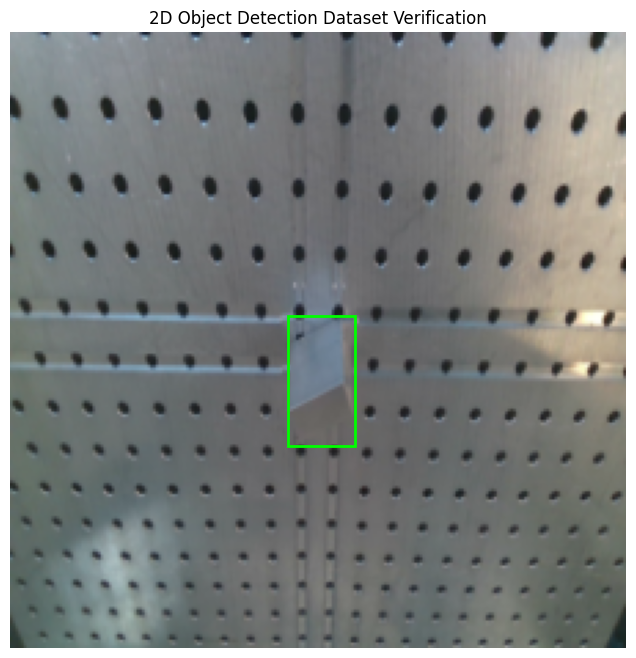

In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Let's verify the 2D bounding boxes
img_t, target = detection_train_dataset[0]

# Convert tensor back to HWC numpy image for plotting
img_display = img_t.numpy().transpose(1, 2, 0)

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img_display)

# Draw bounding boxes
for box in target['boxes']:
    xmin, ymin, xmax, ymax = box.numpy()
    width, height = xmax - xmin, ymax - ymin
    rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)

plt.title("2D Object Detection Dataset Verification")
plt.axis('off')
plt.show()

## Object Detection: Model & DataLoader
Faster R-CNN requires a custom `collate_fn` because each image can have a variable number of bounding boxes. We will use a pre-trained ResNet-50 FPN backbone and modify the box predictor head for our 2 classes (Background + Object).

In [44]:
import torch.optim as optim
import time
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import random_split, DataLoader

In [52]:
train_size = int(0.8 * len(detection_train_dataset))
val_size = len(detection_train_dataset) - train_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(detection_train_dataset, [train_size, val_size], generator=generator)

BATCH_SIZE = 32
# Redefine train_loader_det and create val_loader_det using the collate_fn from previous cell
train_loader_det = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader_det = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
print(f"Created Train/Val split: {len(train_dataset)} train, {len(val_dataset)} val samples.")

Created Train/Val split: 800 train, 200 val samples.


In [53]:
def get_detection_model(num_classes):
    # Load a pre-trained Faster R-CNN model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one for our number of classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# 2 classes: background (0) and object (1)
num_classes = 2
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

detection_model = get_detection_model(num_classes)
detection_model.to(device)

Faster R-CNN model loaded on cuda.


## Training Loop
In PyTorch, Faster R-CNN automatically computes the classification and bounding box regression losses when in `.train()` mode.

Epoch 1/5 [Val]: 100%|██████████| 7/7 [00:09<00:00,  1.35s/it]


Epoch [1/5] | Time: 88.9s | Train Loss: 0.5819 | Val Loss: 0.4352


Epoch 2/5 [Val]: 100%|██████████| 7/7 [00:09<00:00,  1.35s/it]


Epoch [2/5] | Time: 87.8s | Train Loss: 0.3489 | Val Loss: 0.3579


Epoch 3/5 [Val]: 100%|██████████| 7/7 [00:09<00:00,  1.35s/it]


Epoch [3/5] | Time: 88.7s | Train Loss: 0.3107 | Val Loss: 0.3267


Epoch 4/5 [Val]: 100%|██████████| 7/7 [00:09<00:00,  1.35s/it]


Epoch [4/5] | Time: 88.2s | Train Loss: 0.2864 | Val Loss: 0.3304


Epoch 5/5 [Val]: 100%|██████████| 7/7 [00:09<00:00,  1.35s/it]


Epoch [5/5] | Time: 88.2s | Train Loss: 0.2836 | Val Loss: 0.3269
Training finished!


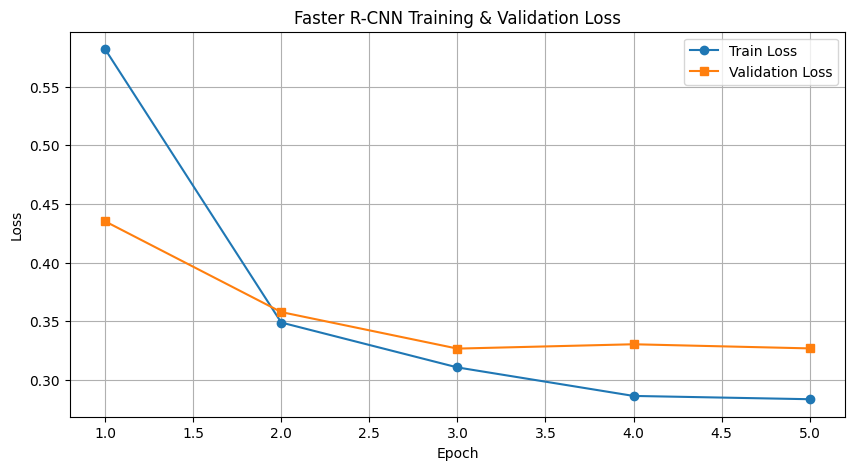

In [54]:
# Optimizer and Learning Rate Scheduler
params = [p for p in detection_model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 5
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # ---------- TRAINING ----------
    detection_model.train()
    epoch_train_loss = 0
    start_time = time.time()

    for images, targets in tqdm(train_loader_det, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = detection_model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_train_loss += losses.item()

    lr_scheduler.step()
    avg_train_loss = epoch_train_loss / len(train_loader_det)
    train_losses.append(avg_train_loss)

    # ---------- EVALUATION ----------
    # torchvision's Faster R-CNN only computes losses in .train() mode.
    # In .eval() mode, it returns bounding box predictions.
    # To calculate validation loss, we keep it in .train() but use torch.no_grad().
    epoch_val_loss = 0
    with torch.no_grad():
        for images, targets in tqdm(val_loader_det, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = detection_model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            epoch_val_loss += losses.item()

    avg_val_loss = epoch_val_loss / max(1, len(val_loader_det))
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {time.time() - start_time:.1f}s | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

print("Training finished!")

# ---------- PLOTTING ----------
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Faster R-CNN Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


## Evaluation & Visualization
Let's put the model in `.eval()` mode and visualize the predicted bounding boxes compared to the ground truth.

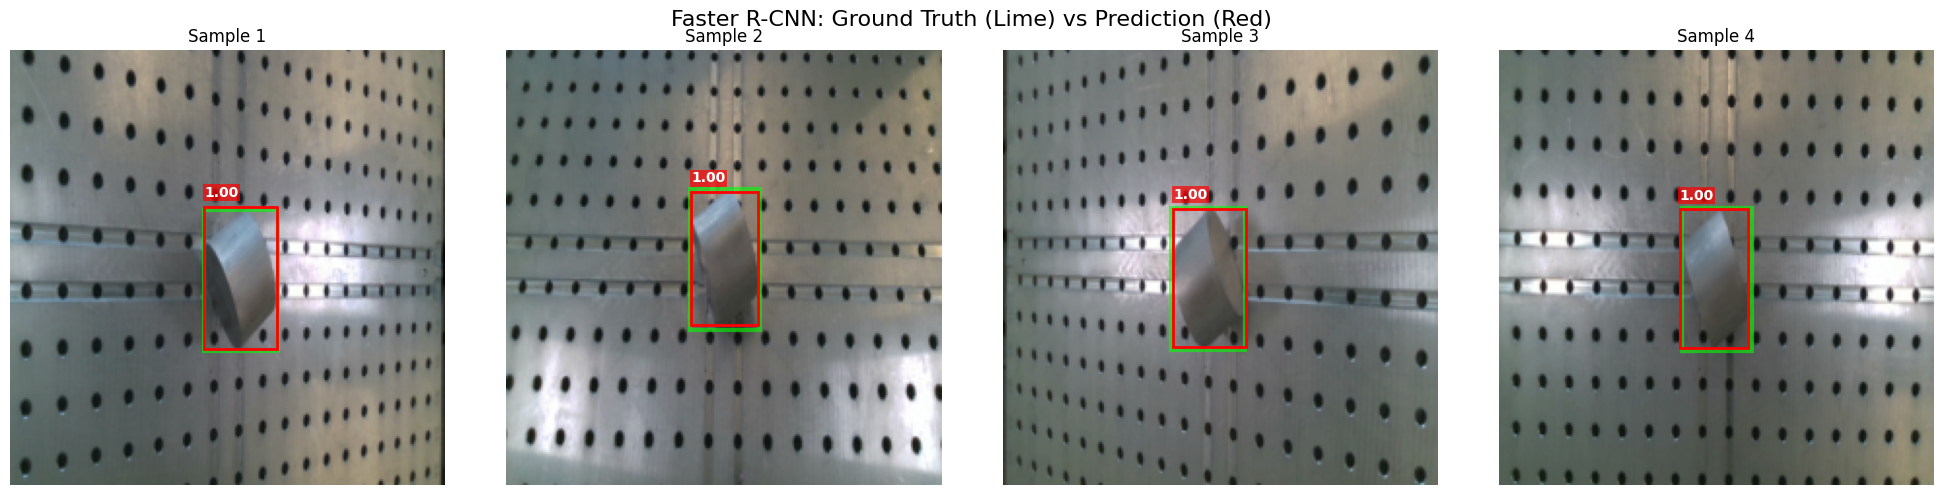

In [60]:
detection_model.eval()

num_vis = 4
fig, axes = plt.subplots(1, num_vis, figsize=(20, 5))

with torch.no_grad():
    for i in range(num_vis):
        # Fetch some images from the dataset
        img_t, target = detection_train_dataset[i + 100]

        # Forward pass (expects a list of tensors)
        prediction = detection_model([img_t.to(device)])[0]

        # Format image for matplotlib
        img_display = img_t.numpy().transpose(1, 2, 0)
        ax = axes[i]
        ax.imshow(img_display)

        # Draw Ground Truth (Lime, semi-transparent)
        for box in target['boxes']:
            xmin, ymin, xmax, ymax = box.numpy()
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=3, edgecolor='lime', facecolor='none', alpha=0.6)
            ax.add_patch(rect)

        # Draw Predictions (Red)
        boxes = prediction['boxes'].cpu().numpy()
        scores = prediction['scores'].cpu().numpy()

        # Filter by a confidence score threshold
        confidence_threshold = 0.5
        for box, score in zip(boxes, scores):
            if score > confidence_threshold:
                xmin, ymin, xmax, ymax = box
                rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                         linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                ax.text(xmin, ymin - 5, f"{score:.2f}", color='white', fontsize=10, fontweight='bold',
                        bbox=dict(facecolor='red', alpha=0.7, edgecolor='none', pad=1))

        ax.set_title(f"Sample {i+1}")
        ax.axis('off')

plt.suptitle("Faster R-CNN: Ground Truth (Lime) vs Prediction (Red)", fontsize=16)
plt.tight_layout()
plt.show()

In [61]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 134.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=95d908aed655c7da314a81e69a8ec060cb732f75e3dcb82de07b9ca6be91c1a0
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


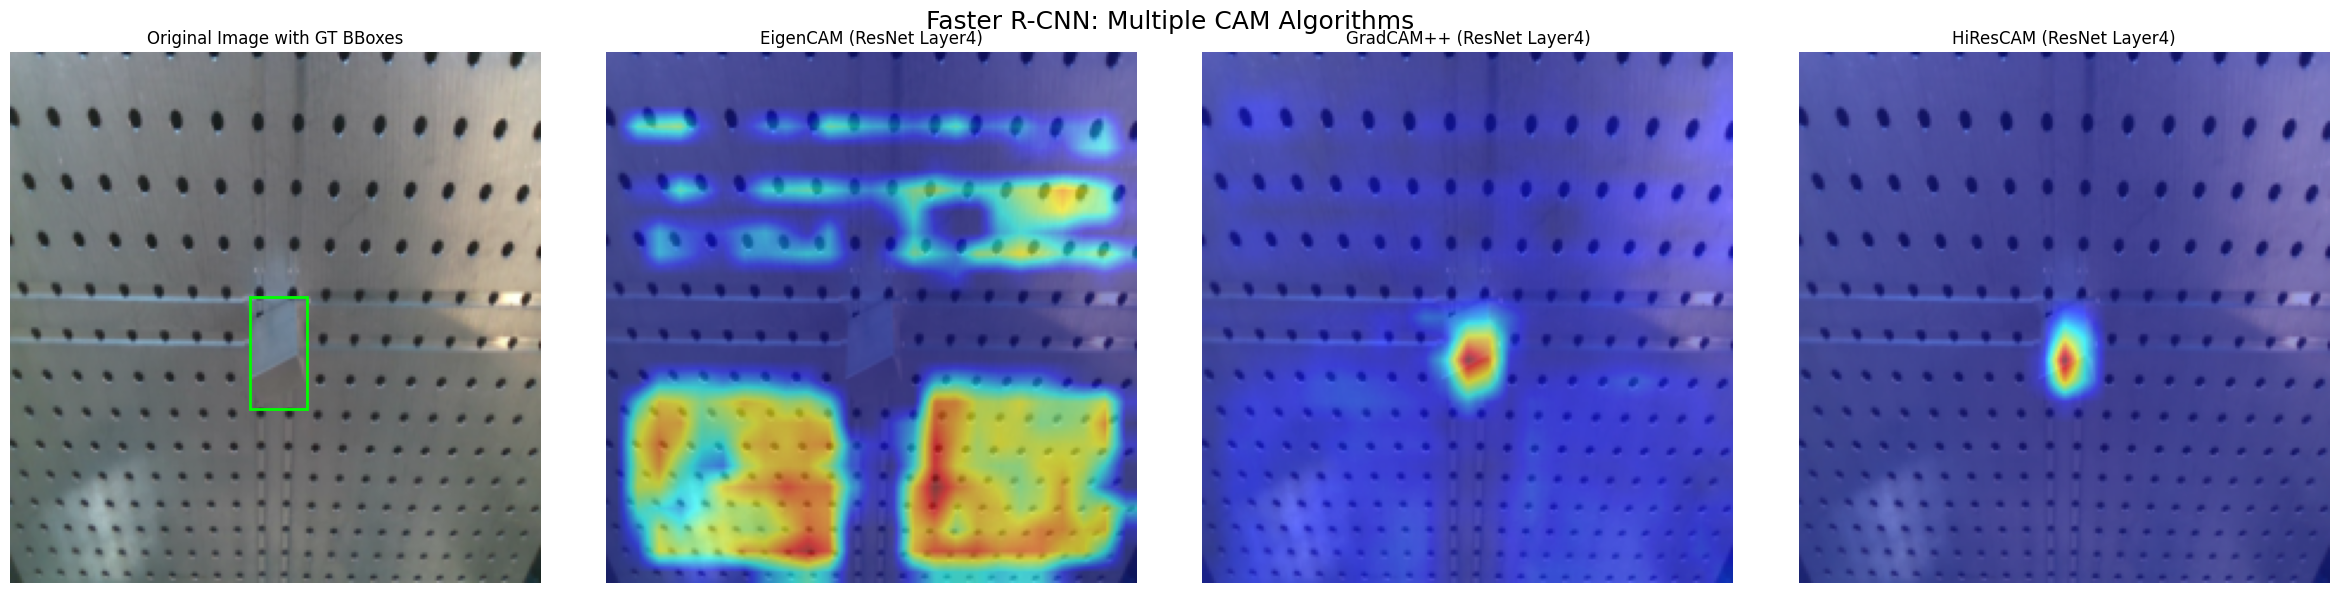

In [62]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pytorch_grad_cam import EigenCAM, GradCAMPlusPlus, HiResCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Wrapper to make Faster R-CNN compatible with pytorch_grad_cam
class DetModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        outputs = self.model(x)
        # For gradient-based CAMs (GradCAM++, HiResCAM), we need a differentiable output.
        # Summing all box confidence scores forces gradients to highlight all detected objects!
        if len(outputs[0]['scores']) > 0:
            return outputs[0]['scores'].sum().view(1, 1)
        return torch.zeros((x.size(0), 1), device=x.device, requires_grad=True)

wrapped_model = DetModelWrapper(detection_model)
wrapped_model.eval()

target_layers = [detection_model.backbone.body.layer4]

img_t, target = detection_train_dataset[0]
input_tensor = img_t.unsqueeze(0).to(device)

# Prepare image for visualization
rgb_img = img_t.numpy().transpose(1, 2, 0)
rgb_img = np.clip(rgb_img, 0, 1)

# Dictionary of CAM methods to run
cam_algorithms = {
    "EigenCAM": EigenCAM,
    "GradCAM++": GradCAMPlusPlus,
    "HiResCAM": HiResCAM
}

cam_images = {}

for name, CamClass in cam_algorithms.items():
    with CamClass(model=wrapped_model, target_layers=target_layers) as cam:
        # targets=None automatically uses our sum of scores output
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)
        grayscale_cam = grayscale_cam[0]
        cam_images[name] = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Plotting
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# 1. Original Image
axes[0].imshow(rgb_img)
axes[0].set_title("Original Image with GT BBoxes")
axes[0].axis('off')
for box in target['boxes']:
    xmin, ymin, xmax, ymax = box.numpy()
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                              linewidth=2, edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect)

# 2-4. CAM Outputs
for idx, (name, img) in enumerate(cam_images.items()):
    axes[idx + 1].imshow(img)
    axes[idx + 1].set_title(f"{name} (ResNet Layer4)")
    axes[idx + 1].axis('off')

plt.suptitle("Faster R-CNN: Multiple CAM Algorithms", fontsize=18)
plt.tight_layout()
plt.show()
